In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "1-OMB8YkgR1omP-RxY-2ha3FUsJ-Kjo8G5jRmsy_WYLE"
GID = "1898071824"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'pass', 'aluno']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,pass,aluno
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,D,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,D,2
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,C,3
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,C,4
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,C,5


In [ ]:
FEATURES = ["Hours_Studied", "Attendance", "Sleep_Hours", "Tutoring_Sessions", "Previous_Scores", "Physical_Activity"]


TARGET = "pass"            # coluna F (classe)

for col in FEATURES :
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())


Distribuição do target:
pass
d    9828
c    3154
f     136
b      52
a      44
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['a', 'b', 'c', 'd', 'f']
Total linhas válidas: 13214


In [ ]:
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))


Treino: 10572 | Teste: 2642


In [ ]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=13214) ===


,qtd,%
pass,,
d,9828,74.4
c,3154,23.9
f,136,1.0
b,52,0.4
a,44,0.3



=== Treino (n=10572) ===


,qtd,%
pass,,
d,7876,74.5
c,2504,23.7
f,112,1.1
b,42,0.4
a,38,0.4



=== Teste (n=2642) ===


,qtd,%
pass,,
d,1952,73.9
c,650,24.6
f,24,0.9
b,10,0.4
a,6,0.2


In [ ]:
# Modelo KNN
K = 2
WEIGHTS = "uniform"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=2))])

In [ ]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))


Features usadas: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Previous_Scores', 'Physical_Activity']
Acurácia: 0.8959121877365632

Relatório:
              precision    recall  f1-score   support

           a       0.43      1.00      0.60         6
           b       0.47      0.80      0.59        10
           c       0.76      0.94      0.84       650
           d       0.96      0.89      0.93      1952
           f       0.33      0.08      0.13        24

    accuracy                           0.90      2642
   macro avg       0.59      0.74      0.62      2642
weighted avg       0.91      0.90      0.90      2642

Matriz de confusão (real x previsto):
[[   6    0    0    0    0]
 [   0    8    0    2    0]
 [   1    1  608   40    0]
 [   7    8  190 1743    4]
 [   0    0    0   22    2]]


In [ ]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[["aluno"] + FEATURES + [ TARGET, "classe_prevista"]])

,aluno,Hours_Studied,Attendance,Sleep_Hours,Tutoring_Sessions,Previous_Scores,Physical_Activity,pass,classe_prevista
0,8414,22,89,8,4,78,3,c,c
1,4817,28,85,9,2,81,3,c,c
2,13009,15,75,6,1,83,2,d,d
3,1356,4,88,6,1,87,4,d,d
4,4465,17,73,9,0,78,3,d,d
...,...,...,...,...,...,...,...,...,...
2637,8450,17,94,7,1,78,3,c,c
2638,9203,7,69,8,1,54,2,b,d
2639,9702,15,67,7,0,94,2,d,d
2640,2544,18,91,7,1,63,4,d,c



=== Árvore de decisão ===
Features usadas: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Previous_Scores', 'Physical_Activity']
Acurácia: 0.9542013626040878

Relatório:
              precision    recall  f1-score   support

           a       0.60      1.00      0.75         6
           b       0.67      0.80      0.73        10
           c       0.93      0.91      0.92       650
           d       0.97      0.97      0.97      1952
           f       0.75      0.75      0.75        24

    accuracy                           0.95      2642
   macro avg       0.78      0.89      0.82      2642
weighted avg       0.95      0.95      0.95      2642

Matriz de confusão (real x previsto):
[[   6    0    0    0    0]
 [   0    8    0    2    0]
 [   2    0  593   55    0]
 [   2    4   44 1896    6]
 [   0    0    0    6   18]]


,aluno,Hours_Studied,Attendance,Sleep_Hours,Tutoring_Sessions,Previous_Scores,Physical_Activity,pass,classe_prevista_arvore
0,8414,22,89,8,4,78,3,c,c
1,4817,28,85,9,2,81,3,c,c
2,13009,15,75,6,1,83,2,d,d
3,1356,4,88,6,1,87,4,d,d
4,4465,17,73,9,0,78,3,d,d
...,...,...,...,...,...,...,...,...,...
2637,8450,17,94,7,1,78,3,c,c
2638,9203,7,69,8,1,54,2,b,d
2639,9702,15,67,7,0,94,2,d,d
2640,2544,18,91,7,1,63,4,d,d


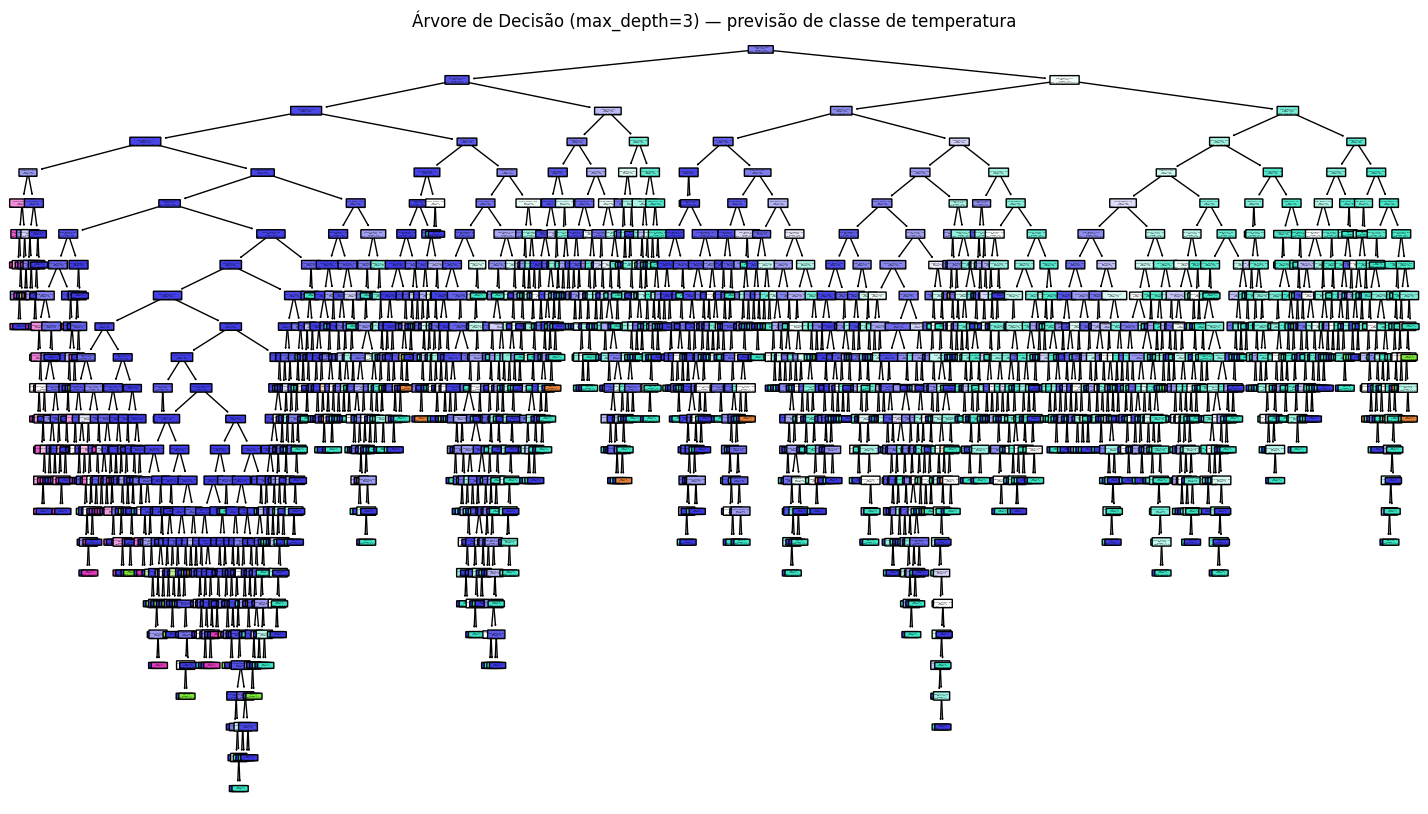

In [ ]:
# ========= Árvore de decisão =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=25,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste (sem mudar sua tabela do KNN, usa outra coluna)
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[["aluno"] + FEATURES + [ TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de classe de temperatura")
plt.show()

In [ ]:
# ========= Naive Bayes =========
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

naive = GaussianNB(var_smoothing=1e-5)

naive.fit(X_train, y_train)
y_pred_naive = naive.predict(X_test)

print("=== Naive Bayes ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_naive))
print("Relatório:")
print(classification_report(y_test, y_pred_naive, target_names=le.classes_, zero_division=0))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_naive))

# Resultado detalhado do teste
test_df["classe_prevista_naive"] = le.inverse_transform(y_pred_naive)
display(test_df[["aluno"] + FEATURES + [TARGET, "classe_prevista_naive"]].head())

=== Naive Bayes ===
Features usadas: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Previous_Scores', 'Physical_Activity']
Acurácia: 0.8618470855412567
Relatório:
              precision    recall  f1-score   support

           a       0.00      0.00      0.00         6
           b       0.00      0.00      0.00        10
           c       0.85      0.60      0.71       650
           d       0.86      0.97      0.91      1952
           f       1.00      0.04      0.08        24

    accuracy                           0.86      2642
   macro avg       0.54      0.32      0.34      2642
weighted avg       0.86      0.86      0.85      2642

Matriz de confusão (real x previsto):
[[   0    0    1    5    0]
 [   0    0    0   10    0]
 [   0    0  392  258    0]
 [   0    0   68 1884    0]
 [   0    0    0   23    1]]


,aluno,Hours_Studied,Attendance,Sleep_Hours,Tutoring_Sessions,Previous_Scores,Physical_Activity,pass,classe_prevista_naive
0,8414,22,89,8,4,78,3,c,c
1,4817,28,85,9,2,81,3,c,c
2,13009,15,75,6,1,83,2,d,d
3,1356,4,88,6,1,87,4,d,d
4,4465,17,73,9,0,78,3,d,d


In [ ]:
# ========= Regras =========
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def regra_passou_v2(row):
    pontos = 0
    if row["Hours_Studied"] >= 15: pontos += 1
    if row["Attendance"] >= 85: pontos += 2
    if row["Previous_Scores"] >= 80: pontos += 4
    elif row["Previous_Scores"] >= 60: pontos += 2
    if row["Sleep_Hours"] >= 7: pontos += 1
    if row["Tutoring_Sessions"] >= 2: pontos += 1

    if pontos >= 8: return "a"
    elif pontos >= 6: return "b"
    elif pontos >= 4: return "c"
    elif pontos >= 1: return "d"
    else: return "f"

# Aplicando a nova lógica
y_pred_regras_texto = test_df.apply(regra_passou_v2, axis=1)
y_pred_regras = le.transform(y_pred_regras_texto)

print("=== Regras ===")
print("Acurácia:", accuracy_score(y_test, y_pred_regras))
print("Relatório:")
print(classification_report(y_test, y_pred_regras, target_names=le.classes_, zero_division=0))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_regras))

# Resultado detalhado do teste
test_df["classe_prevista_regras"] = y_pred_regras_texto
display(test_df[["aluno"] + FEATURES + [TARGET, "classe_prevista_regras"]].head())

=== Regras ===
Acurácia: 0.24791824375473126
Relatório:
              precision    recall  f1-score   support

           a       0.00      0.17      0.01         6
           b       0.00      0.10      0.00        10
           c       0.17      0.24      0.20       650
           d       0.90      0.26      0.40      1952
           f       0.20      0.04      0.07        24

    accuracy                           0.25      2642
   macro avg       0.25      0.16      0.13      2642
weighted avg       0.71      0.25      0.34      2642

Matriz de confusão (real x previsto):
[[  1   3   0   2   0]
 [  0   1   3   6   0]
 [222 241 154  33   0]
 [ 70 619 761 498   4]
 [  0   2   5  16   1]]


,aluno,Hours_Studied,Attendance,Sleep_Hours,Tutoring_Sessions,Previous_Scores,Physical_Activity,pass,classe_prevista_regras
0,8414,22,89,8,4,78,3,c,b
1,4817,28,85,9,2,81,3,c,a
2,13009,15,75,6,1,83,2,d,c
3,1356,4,88,6,1,87,4,d,b
4,4465,17,73,9,0,78,3,d,c
